In [1]:
import numpy as np
import matplotlib.pyplot as plt

from math import exp, sqrt, pi
import scipy.stats

In [2]:
def bivariate_normal(x, m, C): #m is the mean vector, C is COVARIANCE matrix
    C_inv = np.linalg.inv(C)
    xm = x - m #centralized version of x vector
    likelihood = (xm.T)@(C_inv)@(xm)
    return exp(-0.5*(likelihood.item()))

def vector(x,y):
    return np.array([[x],[y]])

In [3]:
p=0.2 #correlation coefficient
std_x = 1
std_y = 2

m = vector(0,0)

C = np.array([[std_x**2,std_x*std_y*p],[std_x*std_y*p,std_y**2]])

# Gibbs Sampling

$W$ is the random vector $\begin{pmatrix} X \\ Y \end{pmatrix}$ which we want to sample from a joint density function $p(x,y)$

Let the $i^{th}$ sample of W be $\overline{w_i} = \begin{pmatrix} x_i \\ y_i \end{pmatrix}$

$W \text{ is sampled from conditionals: } \frac{1}{2} \left[p(x_{i+1}|y_{i+1})p(y_{i+1}|x_{i}) + p(y_{i+1}|x_{i+1})p(x_{i+1}|y_{i}) \right]$

In [4]:
x_samples = [1]
y_samples = [1]
N = 10**6

mu_x = m[0,0]
mu_y = m[1,0]


for i in range(N):
    curr_x, curr_y = x_samples[-1], y_samples[-1]
    if np.random.random() < 0.5:
        prop_y = np.random.normal(mu_y + p*std_y*(curr_x - mu_x)/std_x, sqrt((1-p**2)*std_y**2))
        prop_x = np.random.normal(mu_x + p*std_x*(prop_y - mu_y)/std_y, sqrt((1-p**2)*std_x**2))

    
        x_samples.append(prop_x)
        y_samples.append(prop_y)

    else:
        prop_x = np.random.normal(mu_x + p*std_x*(curr_y - mu_y)/std_y, sqrt((1-p**2)*std_x**2))
        prop_y = np.random.normal(mu_y + p*std_y*(prop_x - mu_x)/std_x, sqrt((1-p**2)*std_y**2))

        x_samples.append(prop_x)
        y_samples.append(prop_y)

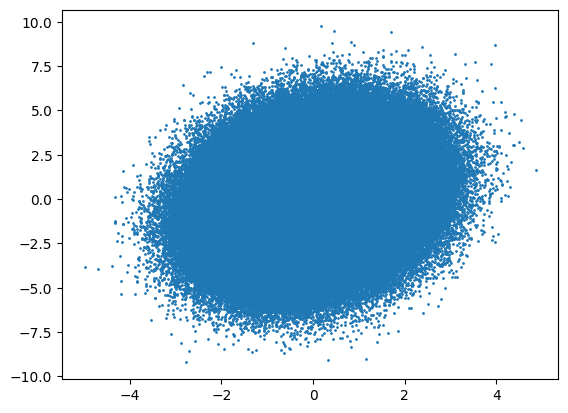

In [5]:
burn_in = 1000
x_retained = x_samples[burn_in:]
y_retained = y_samples[burn_in:]

plt.scatter(x_retained, y_retained, s=1)

In [6]:
print("Covariance Matrix of samples:", np.cov([x_retained, y_retained]))
print("Original Covariance Matrix:", C)

Covariance Matrix of samples: [[1.00042983 0.40103681]
 [0.40103681 4.00042034]]
Original Covariance Matrix: [[1.  0.4]
 [0.4 4. ]]


# Correlation between samples of the Gibbs Sampler

This is a random process, so we can find the autocorrelation between successive samples. 

If we had an ideal sampler, it would be i.i.d. and the autocorrelation would be 0. But this is not an i.i.d. sample. Each sample depends on the previous samples

In [ ]:
print(scipy.stats.pearsonr(y_retained[:-1], y_retained[1:])[0]) #samples are very slightly correlated. As p is increased this correlation also increases.

0.03860014878132088


# High Dimensional Integration with Monte Carlo